# Human Activity Recognition with PCA

This notebook builds a clean, presentation-ready PCA analysis on the **UCI Human Activity Recognition Using Smartphones** dataset.

The goal is simple: reduce a high-dimensional activity dataset to a small number of principal components and check whether the major human activities are still visually distinguishable.

## 1. Dataset Overview and Understanding

The UCI Human Activity Recognition (HAR) dataset contains smartphone sensor measurements collected from **30 volunteers**.

- Each volunteer wore a **Samsung Galaxy S II** on the waist.
- The phone's **accelerometer** and **gyroscope** recorded motion signals at **50 Hz**.
- Each row in this dataset represents **one 2.56-second sliding window** of sensor data.
- The six activity labels are: `WALKING`, `WALKING_UPSTAIRS`, `WALKING_DOWNSTAIRS`, `SITTING`, `STANDING`, and `LAYING`.
- Instead of raw signals, the dataset provides **561 engineered features** built from time-domain and frequency-domain summaries.

This makes the dataset useful for a presentation on dimension reduction: it is realistic, high-dimensional, and still easy to explain.

### Files Loaded by the Dataset

The `load_har_dataset` function loads the following specific files from the UCI HAR Dataset directory:

**Core metadata files:**
- `features.txt` - Contains the names of the 561 engineered features
- `activity_labels.txt` - Maps numeric activity IDs (1-6) to readable labels like "WALKING", "SITTING", etc.

**Training data files:**
- `train/X_train.txt` - The feature matrix for training samples (7,352 rows × 561 features)
- `train/y_train.txt` - Activity labels for training samples (7,352 rows)
- `train/subject_train.txt` - Subject IDs for training samples (7,352 rows)

**Test data files:**
- `test/X_test.txt` - The feature matrix for test samples (2,947 rows × 561 features)
- `test/y_test.txt` - Activity labels for test samples (2,947 rows)
- `test/subject_test.txt` - Subject IDs for test samples (2,947 rows)

The function combines the train and test data into a single DataFrame with 10,299 rows total. Note that it **does not load** the raw inertial signal files in the `Inertial Signals/` subdirectories - those contain the original 128-sample time series data that was used to engineer the 561 features, but this analysis uses only the pre-processed features.

**How the Activity Labels Work:**
- **Row alignment**: Each row `i` in the feature files (`X_train.txt`, `X_test.txt`) corresponds directly to row `i` in the label files (`y_train.txt`, `y_test.txt`) and subject files (`subject_train.txt`, `subject_test.txt`).
- **Label mapping**: The integer in the label files (1-6) is the activity ID that maps to the human-readable activity name in `activity_labels.txt`:
  - `1` → `WALKING`
  - `2` → `WALKING_UPSTAIRS`
  - `3` → `WALKING_DOWNSTAIRS`
  - `4` → `SITTING`
  - `5` → `STANDING`
  - `6` → `LAYING`
- This structure ensures each sensor window (row) has its corresponding activity classification, making the dataset ready for supervised learning tasks.

### How the 561 Features Were Engineered

The dataset authors started with raw smartphone sensors and applied sophisticated signal processing to create 561 features. Understanding this pipeline helps explain why PCA can compress the data effectively—the features themselves are already summaries of underlying patterns.

**Step 1: Raw Sensor Signals** (starting point)
- Samsung Galaxy S II smartphone was worn on the waist during each activity
- **Accelerometer** (measures linear motion): 3 axes (X, Y, Z) → captured acceleration in three directions
- **Gyroscope** (measures rotation): 3 axes (X, Y, Z) → captured angular velocity in three directions
- Sampling rate: **50 Hz** (50 measurements per second)
- Each observation window: **2.56 seconds** → 128 samples per window

**Step 2: Signal Preprocessing**
- Applied a **median filter** and **3rd order low pass Butterworth filter** (cutoff frequency 20 Hz) to remove noise
- Separated acceleration into two components using a low pass filter (cutoff frequency 0.3 Hz):
  - **Body acceleration**: motion due to the person's movement
  - **Gravity acceleration**: constant pull of gravity (influenced by body orientation)

**Step 3: Derived Additional Signals**
- **Jerk signals**: Time derivative of acceleration (how rapidly acceleration is changing)
  - `tBodyAccJerk`, `tBodyGyroJerk`, etc.
- **Magnitude signals**: Euclidean norm of the 3D vectors (overall strength regardless of direction)
  - `tBodyAccMag = sqrt(X² + Y² + Z²)` for acceleration
  - `tBodyGyroMag` for angular velocity, etc.

**Step 4: Domain Transformation**
- Applied **Fast Fourier Transform (FFT)** to convert time-domain signals into frequency domain
- Frequency domain reveals which movement patterns are stronger at which frequencies
- Features with prefix `f` (like `fBodyAcc`) are frequency-domain; `t` prefix are time-domain

**Step 5: Feature Extraction**
From each processed signal, the authors calculated **16 different statistics**:

| Statistic | Meaning |
|-----------|---------|
| `mean()` | Average value over the 2.56-second window |
| `std()` | Standard deviation (variability) |
| `mad()` | Median absolute deviation (robustness to outliers) |
| `max()` | Maximum value in the window |
| `min()` | Minimum value in the window |
| `energy()` | Sum of squared values (total power in the signal) |
| `iqr()` | Interquartile range (spread of middle 50%) |
| `entropy()` | Signal complexity/disorder |
| `arCoeff()` | Autoregression coefficients (how past values predict future) |
| `maxInds()` | Frequency component with largest magnitude |
| `meanFreq()` | Weighted average frequency |
| `sma()` | Signal magnitude area (overall motion intensity) |
| `skewness()` | Asymmetry of the distribution |
| `kurtosis()` | Heaviness of tails in the distribution |
| `correlation()` | Linear relationship between two signals |
| `bandsEnergy()` | Energy in different frequency bands |

**Result: 561 Features**

The authors applied these statistics to ~17 different processed signal types (body acc, gravity acc, body jerk, magnitudes, frequency versions) × 3 axes + magnitudes (no axes) × many statistics = **561 total features**.

**Why This Matters for PCA:**
- These 561 features are already **highly processed summaries** of raw signals
- They capture time-domain behavior (mean, variability, shape) and frequency-domain behavior (dominant frequencies, energy distribution)
- Many features are mathematically related (e.g., `max()` and `min()` can predict `range`)
- PCA is very effective here because it can find the combinations that matter most for separating activities

### Example Features Decoded

To understand what each of the 561 feature names means, let's decode a few real examples:

**`tBodyAcc-mean()-X`**
- `t` = time-domain signal (not frequency domain)
- `BodyAcc` = body linear acceleration (motion due to the person, not gravity)
- `-mean()` = average value over the 2.56-second window
- `-X` = measured along the X-axis (typically left-right direction)
- **Meaning**: "How much does the person average leftward/rightward movement during this activity window?"

**`tBodyAccJerk-std()-Y`**
- `t` = time domain
- `BodyAccJerk` = rate of change of body acceleration (how quickly movements start/stop)
- `-std()` = standard deviation (how much does this quantity vary?)
- `-Y` = along the Y-axis (typically forward-backward direction)
- **Meaning**: "How variable is the rate of forward/backward acceleration?"

**`fBodyGyro-energy()-Z`**
- `f` = frequency-domain signal (result of Fourier Transform)
- `BodyGyro` = angular velocity (rotation of the body)
- `-energy()` = sum of squared values (total rotational power)
- `-Z` = around the Z-axis (typically vertical/spinning axis)
- **Meaning**: "How much total rotational energy occurs around the vertical axis, and at what frequencies?"

**`tBodyAccMag-mean()`**
- `t` = time domain
- `BodyAccMag` = magnitude of body acceleration (overall strength of movement, ignoring direction)
- `-mean()` = average over the window
- (no `-X, -Y, -Z` because magnitude is already one scalar value per time point)
- **Meaning**: "What is the average overall strength of movement, regardless of direction?"

**Why These Are Useful:**
- **Walking** has strong, repetitive acceleration patterns
- **Climbing stairs** has different energy distribution (more effort in certain frequencies)
- **Sitting** has minimal jerk and energy
- **Standing** differs from sitting mainly in frequency content and gravity components

The 561 features capture all these nuances, and PCA will find which combinations are most predictive.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data_loader as data_loader
import src.pca_analysis as pca_analysis
import src.preprocessing as preprocessing
import src.utils as utils
import src.visualization as visualization

# Reload local project modules so notebook reruns pick up recent edits.
data_loader = importlib.reload(data_loader)
pca_analysis = importlib.reload(pca_analysis)
preprocessing = importlib.reload(preprocessing)
utils = importlib.reload(utils)
visualization = importlib.reload(visualization)

from src.data_loader import build_feature_group_summary, load_har_dataset
from src.pca_analysis import (
    attach_metadata_to_scores,
    build_component_profile,
    build_component_summary,
    build_variance_target_summary,
    fit_full_pca,
    get_top_feature_loadings,
    summarize_activity_centroids,
    summarize_loading_groups,
)
from src.preprocessing import (
    build_dataset_checks_table,
    build_dimension_comparison_table,
    get_class_distribution,
    get_sorted_activity_labels,
    prepare_pca_input,
)
from src.utils import ensure_project_directories, resolve_dataset_dir, save_table, set_random_seed
from src.visualization import (
    plot_class_distribution,
    plot_cumulative_explained_variance,
    plot_explained_variance,
    plot_pca_scatter,
    set_plot_style,
)

paths = ensure_project_directories(PROJECT_ROOT)
set_random_seed(42)
set_plot_style()

dataset_dir = resolve_dataset_dir(project_root=PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {dataset_dir}")

Project root: C:\Users\Nimish\Desktop\human-activity-pca
Dataset directory: C:\Users\Nimish\Desktop\human-activity-pca\data\raw\UCI HAR Dataset


In [2]:
har_df = load_har_dataset(dataset_dir)

overview_table = pd.DataFrame(
    {
        "summary_item": [
            "Rows in the combined dataset",
            "Engineered features per row",
            "Unique volunteers",
            "Activity classes",
            "What one row represents",
        ],
        "value": [
            len(har_df),
            561,
            har_df["subject_id"].nunique(),
            har_df["activity_label"].nunique(),
            "One 2.56-second sliding window of smartphone sensor data",
        ],
    }
)

feature_group_summary = build_feature_group_summary(har_df.columns[4:])

save_table(overview_table, paths["tables"] / "dataset_overview.csv")
save_table(feature_group_summary, paths["tables"] / "feature_group_summary.csv")

display(overview_table)
display(feature_group_summary)

,summary_item,value
0,Rows in the combined dataset,10299
1,Engineered features per row,561
2,Unique volunteers,30
3,Activity classes,6
4,What one row represents,One 2.56-second sliding window of smartphone s...


,domain,signal_family,feature_count
0,Angle / other,Angle features,7
1,Frequency domain,Body acceleration,79
2,Frequency domain,Body acceleration jerk,79
3,Frequency domain,Body gyroscope,79
4,Frequency domain,Body acceleration jerk magnitude,13
5,Frequency domain,Body acceleration magnitude,13
6,Frequency domain,Body gyroscope jerk magnitude,13
7,Frequency domain,Body gyroscope magnitude,13
8,Time domain,Body acceleration,40
9,Time domain,Body acceleration jerk,40


## 2. Why Dimension Reduction Is Useful Here

This dataset has **561 features**, which is far too many to visualize directly.

If we try to think about every feature at once, it becomes hard to see the overall structure of the data. PCA helps by compressing the information into a smaller number of summary axes called **principal components**.

Reducing the data to **2 principal components** gives us a practical way to make a scatter plot and check whether similar activities cluster together in a lower-dimensional view.

## 3. Load the Dataset and Perform Initial Checks / Preprocessing

For this notebook, the original **train** and **test** files are merged into one analysis-ready table.

That is a reasonable choice here because the goal is **exploration and visualization**, not training a predictive classifier. Before PCA, we will:

- inspect the overall shape,
- check for missing values,
- confirm the class labels,
- review class distribution,
- standardize the numeric features.

Standardization matters because PCA is sensitive to scale, so features should be placed on a comparable footing first.

### Why Standardization Matters for PCA

Before PCA, all 561 features are on very different scales. For example:
- Some features might range from -50 to +50
- Others might range from -0.001 to +0.001
- Still others from 0 to 1000

**What happens without standardization:**
PCA finds the directions of maximum variance. If one feature naturally has much larger numerical values than others, it will dominate the first principal component simply because of scale, not because it actually contains more meaningful information.

**The standardization transformation:**
For each feature, we apply this formula:

$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ is the original value
- $\mu$ is the feature's mean
- $\sigma$ is the feature's standard deviation
- $z$ is the standardized value

**What this accomplishes:**
- All features now have **mean = 0** (centered around zero)
- All features now have **standard deviation = 1** (all on the same scale)
- A value of +2 now means "2 standard deviations above the mean" for any feature, making comparisons fair

**Example:**
- Feature A (raw): range = 0 to 1000, mean = 500, std = 200 → After standardization: mean = 0, std = 1
- Feature B (raw): range = -5 to +5, mean = 0, std = 2 → After standardization: mean = 0, std = 1

Now both features are equally important when PCA looks for principal components.

### Standardization: Per-Feature vs Global Mean

**The mean is calculated PER FEATURE (each of the 561 features individually).**

Here's why this is the standard approach and the pros/cons of alternatives:

**What We Actually Do (Per-Feature Standardization):**
```python
# For each feature column independently:
mean_of_feature = feature_column.mean()  # e.g., tBodyAcc-mean()-X has its own mean
std_of_feature = feature_column.std()    # e.g., tBodyAcc-mean()-X has its own std

# Transform each value:
standardized_value = (raw_value - mean_of_feature) / std_of_feature
```

**Why Per-Feature Mean?**
- **PCA assumption**: Each feature should be on comparable footing
- **Scale sensitivity**: PCA finds directions of maximum variance; if one feature naturally has larger values, it dominates
- **Common practice**: This is the **standard** approach for PCA and most machine learning preprocessing

**Alternative: Global Mean (Across All Features)**
```python
# Hypothetical: use one mean for the entire dataset
global_mean = entire_feature_matrix.mean()  # One number for all 561 features
global_std = entire_feature_matrix.std()   # One number for all 561 features

# Transform each value:
standardized_value = (raw_value - global_mean) / global_std
```

**Pros and Cons Comparison:**

| Approach | Pros | Cons |
|----------|------|------|
| **Per-Feature Mean** (What we use) | ✅ Each feature gets fair treatment regardless of natural scale<br>✅ Preserves relative importance within each feature<br>✅ Standard practice for PCA<br>✅ Makes features comparable | ❌ Doesn't account for overall dataset scale<br>❌ Features with naturally small variance get artificially inflated |
| **Global Mean** (Alternative) | ✅ Preserves overall dataset scale<br>✅ All features transformed relative to same baseline | ❌ Features with naturally large values dominate PCA<br>❌ Violates PCA assumptions about comparable scales<br>❌ Not standard practice<br>❌ Would make small-scale features irrelevant |

**Why Per-Feature Is Standard:**
- **Mathematical requirement**: PCA assumes features are on comparable scales
- **Practical evidence**: Global standardization would make features like `tBodyAcc-mean()-X` (range ~2) irrelevant compared to features with larger ranges
- **Literature consensus**: Every PCA tutorial and implementation uses per-feature standardization
- **Our data example**: `tBodyAcc-mean()-X` has std=0.07, while some energy features have std>1. Without per-feature scaling, PCA would ignore the smaller-scale features entirely

**When Global Mean Might Make Sense:**
- If all features were measured in the same units and same scale (rare in practice)
- For some clustering algorithms that don't assume comparable scales
- When you want to preserve the absolute scale of the entire dataset

**Bottom Line:** Per-feature standardization is the right choice here because it ensures PCA finds meaningful patterns across all 561 features, not just the ones with the largest natural variance.

,metric,value
0,Rows (activity windows),10299
1,Feature columns,561
2,Unique subjects,30
3,Activity classes,6
4,Missing values in features,0
5,Training rows,7352
6,Test rows,2947


,activity_label
0,WALKING
1,WALKING_UPSTAIRS
2,WALKING_DOWNSTAIRS
3,SITTING
4,STANDING
5,LAYING


,activity_id,activity_label,count
0,1,WALKING,1722
1,2,WALKING_UPSTAIRS,1544
2,3,WALKING_DOWNSTAIRS,1406
3,4,SITTING,1777
4,5,STANDING,1906
5,6,LAYING,1944


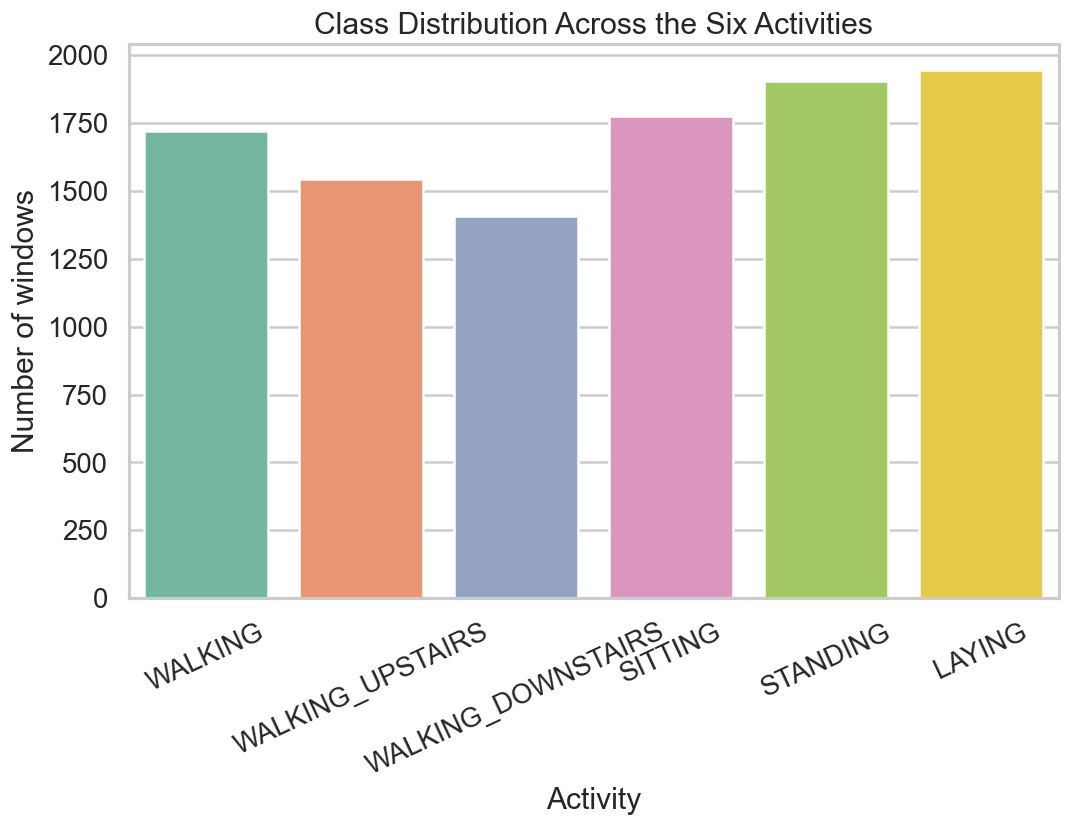

In [3]:
initial_checks = build_dataset_checks_table(har_df)
class_distribution = get_class_distribution(har_df)
confirmed_labels = pd.DataFrame({"activity_label": get_sorted_activity_labels(har_df)})

save_table(initial_checks, paths["tables"] / "initial_checks.csv")
save_table(class_distribution, paths["tables"] / "class_distribution.csv")
save_table(confirmed_labels, paths["tables"] / "confirmed_activity_labels.csv")

display(initial_checks)
display(confirmed_labels)
display(class_distribution)

fig, ax = plot_class_distribution(
    class_distribution,
    save_path=paths["figures"] / "class_distribution.png",
)
plt.show()
plt.close(fig)

In [4]:
X_scaled, feature_columns, scaler = prepare_pca_input(har_df)

scaling_check = pd.DataFrame(
    {
        "check": [
            "Scaled matrix shape",
            "Overall mean after standardization",
            "Overall standard deviation after standardization",
        ],
        "value": [
            str(X_scaled.shape),
            round(float(X_scaled.values.mean()), 4),
            round(float(X_scaled.values.std()), 4),
        ],
    }
)

display(scaling_check)

,check,value
0,Scaled matrix shape,"(10299, 561)"
1,Overall mean after standardization,0.0
2,Overall standard deviation after standardization,1.0


In [5]:
# Show the difference: raw vs standardized data
raw_sample_stats = pd.DataFrame({
    "feature_example": feature_columns[:5],  # Show first 5 features
    "raw_min": [X_scaled.values[:, i].min() * scaler.scale_[i] + scaler.mean_[i] for i in range(5)],
    "raw_max": [X_scaled.values[:, i].max() * scaler.scale_[i] + scaler.mean_[i] for i in range(5)],
    "raw_mean": scaler.mean_[:5],
    "raw_std": scaler.scale_[:5],
    "standardized_min": X_scaled.values[:, :5].min(axis=0),
    "standardized_max": X_scaled.values[:, :5].max(axis=0),
    "standardized_mean": X_scaled.values[:, :5].mean(axis=0),
    "standardized_std": X_scaled.values[:, :5].std(axis=0),
})

# Round for readability
for col in raw_sample_stats.columns[1:]:
    raw_sample_stats[col] = raw_sample_stats[col].round(4)

display(Markdown("### Before vs After: Raw Data vs Standardized Data"))
display(Markdown("**Notice how after standardization, all features have mean ≈ 0 and std ≈ 1**"))
display(raw_sample_stats)

### Before vs After: Raw Data vs Standardized Data

**Notice how after standardization, all features have mean ≈ 0 and std ≈ 1**

,feature_example,raw_min,raw_max,raw_mean,raw_std,standardized_min,standardized_max,standardized_mean,standardized_std
0,tBodyAcc-mean()-X,-1.0,1.0,0.2743,0.0676,-18.8445,10.7306,-0.0,1.0
1,tBodyAcc-mean()-Y,-1.0,1.0,-0.0177,0.0371,-26.4571,27.4130,0.0,1.0
2,tBodyAcc-mean()-Z,-1.0,1.0,-0.1089,0.0530,-16.8031,20.9111,0.0,1.0
3,tBodyAcc-std()-X,-1.0,1.0,-0.6078,0.4387,-0.8941,3.6651,-0.0,1.0
4,tBodyAcc-std()-Y,-1.0,1.0,-0.5102,0.5002,-0.9792,3.0191,0.0,1.0


## 4. Analytical Question

**Can PCA compress the high-dimensional smartphone activity dataset into a small number of components while still preserving enough structure to visually distinguish major human activities?**

### Pipeline at a Glance

`Sensor windows -> engineered features -> standardization -> PCA -> 2D visualization`

This is the full workflow behind the notebook. The raw signals have already been converted into 561 engineered features; our role here is to standardize them, compress them with PCA, and inspect the structure that remains.

## 5. Explain PCA Simply and Apply It

PCA can be explained in plain language as a way to **rotate the data** so that the new axes capture the strongest patterns of variation.

- **PC1** captures the single biggest pattern in the dataset.
- **PC2** captures the next biggest pattern, while being different from PC1.
- The explained variance ratio tells us how much of the dataset's overall variation each component keeps.
- The cumulative explained variance tells us how much total information has been kept after adding more components.

In this project, we fit PCA to the standardized feature matrix, keep the full variance profile, and use the first **2 components** for the main visualization because a 2D view is easy to present and interpret.

In [6]:
top_loading_window = 40

pca_model, explained_variance, pca_scores_2d = fit_full_pca(X_scaled)
pca_scores_with_labels = attach_metadata_to_scores(
    pca_scores_2d,
    har_df[["split", "subject_id", "activity_id", "activity_label"]],
)

component_summary = build_component_summary(explained_variance)
variance_target_summary = build_variance_target_summary(explained_variance, targets=(0.90, 0.95))
dimension_comparison = build_dimension_comparison_table(
    X_scaled,
    pca_scores_2d,
    original_label="Original standardized feature space",
    reduced_label="PCA visualization space",
)
loading_group_summary = summarize_loading_groups(
    pca_model,
    feature_columns,
    components=(1, 2),
    top_n=top_loading_window,
)
component_profile = build_component_profile(loading_group_summary)
top_loadings = get_top_feature_loadings(pca_model, feature_columns, components=(1, 2), top_n=10)
activity_centroids = summarize_activity_centroids(pca_scores_with_labels)

save_table(explained_variance, paths["tables"] / "explained_variance_full.csv")
save_table(component_summary, paths["tables"] / "component_variance_summary.csv")
save_table(variance_target_summary, paths["tables"] / "variance_target_summary.csv")
save_table(dimension_comparison, paths["tables"] / "dimension_comparison.csv")
save_table(loading_group_summary, paths["tables"] / "loading_group_summary.csv")
save_table(component_profile, paths["tables"] / "component_profile.csv")
save_table(top_loadings, paths["tables"] / "top_pc_loadings.csv")
save_table(activity_centroids, paths["tables"] / "activity_centroids.csv")

variance_after_two = float(
    explained_variance.loc[
        explained_variance["component_number"] == 2,
        "cumulative_explained_variance",
    ].iloc[0]
)
components_for_90 = int(
    variance_target_summary.loc[
        variance_target_summary["target_variance"] == "90%",
        "components_needed",
    ].iloc[0]
)
components_for_95 = int(
    variance_target_summary.loc[
        variance_target_summary["target_variance"] == "95%",
        "components_needed",
    ].iloc[0]
)

### Before vs After Dimension Reduction

This is the most concrete way to describe what PCA is doing here.

The number of **rows stays the same** because we still have the same activity windows. What changes is the number of **columns**: PCA compresses the original feature space into a small number of components for visualization.

In [7]:
display(dimension_comparison[["representation", "matrix_shape", "meaning"]])

display(
    Markdown(
        f"Before PCA, the analysis uses **{X_scaled.shape[0]:,} x {X_scaled.shape[1]:,}**. "
        f"After reducing to two principal components, it becomes **{pca_scores_2d.shape[0]:,} x {pca_scores_2d.shape[1]:,}**. "
        "The observations stay the same; PCA only compresses the feature columns."
    )
)

,representation,matrix_shape,meaning
0,Original standardized feature space,"10,299 x 561",All activity windows with the full engineered ...
1,PCA visualization space,"10,299 x 2",The same activity windows shown using only two...


Before PCA, the analysis uses **10,299 x 561**. After reducing to two principal components, it becomes **10,299 x 2**. The observations stay the same; PCA only compresses the feature columns.

## 6. Show Results and Interpretation

The main result visuals below answer two questions:

1. How quickly does PCA explain the total variance?
2. Do the first two components produce a useful 2D view of the six activities?

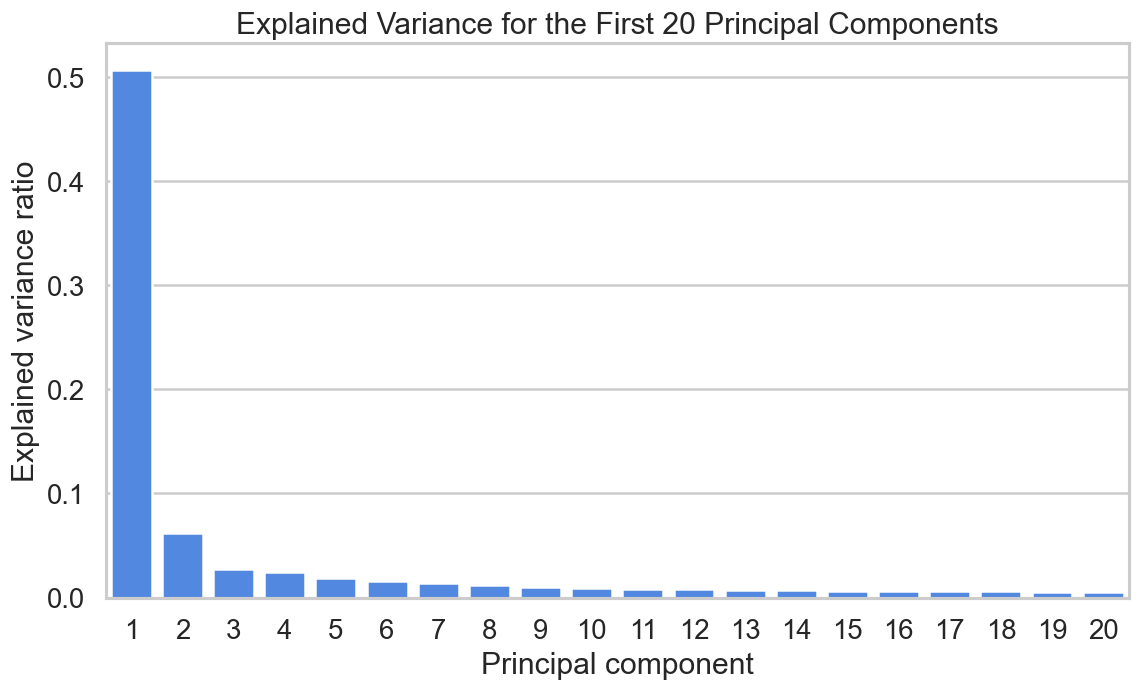

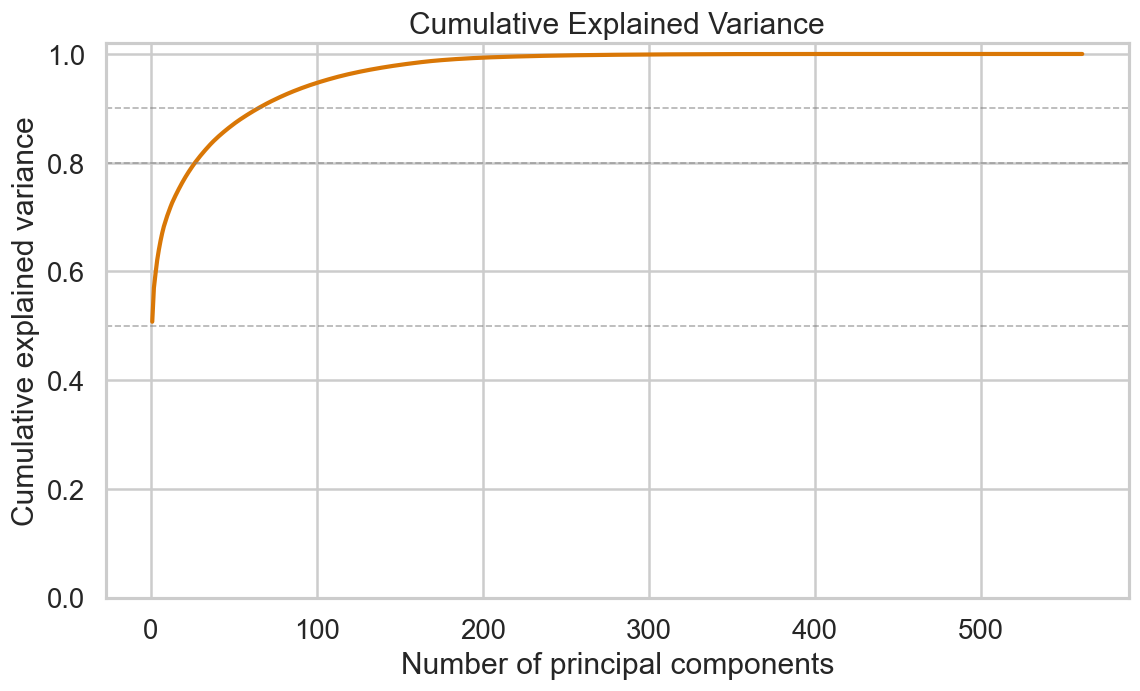

In [8]:
fig, ax = plot_explained_variance(
    explained_variance,
    save_path=paths["figures"] / "explained_variance_scree.png",
    n_components=20,
)
plt.show()
plt.close(fig)

fig, ax = plot_cumulative_explained_variance(
    explained_variance,
    save_path=paths["figures"] / "cumulative_explained_variance.png",
)
plt.show()
plt.close(fig)

### Understanding the Variance Plots

These two figures are the most important diagnostic tools for understanding PCA. Let me explain what each one tells us:

**Figure 1: The Scree Plot (Explained Variance per Component)**

This bar chart shows how much variance each individual principal component captures.

- **Y-axis**: "Explained variance ratio" (what percentage of total variance does this component capture?)
- **X-axis**: Principal component number (PC1, PC2, PC3, ..., up to all 561)
- **What it shows**: PC1 captures the most information, PC2 captures less, PC3 even less, etc.

**How to read it:**
- Look for the "elbow": where the bars drop sharply
- Before the elbow = these components are capturing meaningful structure
- After the elbow = these components capture diminishing returns (mostly noise)
- In this dataset, there's a clear elbow ~around PC3-PC5, meaning most structure is captured by just a few components

**Why it matters:**
- If PC1 captured 90% and PC2 captured 5%, then PC1 is the dominant pattern
- If PC1 captured 10% and PC2 captured 10%, the structure is more distributed
- The slope tells us how quickly information drops off

---

**Figure 2: Cumulative Explained Variance**

This line graph shows the total information preserved as you add more and more components.

- **Y-axis**: "Cumulative explained variance" (what percentage of total information is preserved?)
- **X-axis**: Number of components kept
- **What it shows**: How many components do you need to keep X% of the total information?

**How to read it:**
- The curve starts at 0 and maxes out at 100% (when you keep all 561 components)
- A **steep curve early** = few components are enough (good compression possible)
- A **flat curve** = you need many components to capture the variation (poor compression)
- A horizontal line at the desired threshold = that's your target number of components
  - For 90% variance: draw a line at 90%, see where it crosses the curve, that's the number of components needed
  - Same for 95%, 99%, etc.

**Why it matters:**
- This answers the practical question: "How many components do I actually need?"
- In this dataset, 2 components ≈ 5% of variance (visible as a tiny rise at the start)
- But 90% variance requires ~144 components (a huge drop from 561, but still substantial)
- For visualization (our goal), 2 components is a calculated tradeoff: lose 95% of information to gain readability

---

**Together, What Do They Tell Us?**

1. **The structure is dominated by a few strong patterns** (visible from the steep scree plot)
2. **Most of the variation is spread across many features** (you need ~144 PCs for 90%)
3. **2 PCs are useful for visualization** (they capture the biggest patterns, even if they only keep 5% of total variance)
4. **There's a big drop-off after PC10-20** (high-order PCs contain mostly noise or activity-specific details)

This is typical for real sensor data: many noisy features with a few dominant patterns underneath.

### Why Are 2 Principal Components Still Useful?

Two components do **not** preserve everything, and that is okay.

Here, the goal is **visualization and structure discovery**, not perfect reconstruction of the original 561-feature space. A 2D PCA view is useful because it gives the audience a readable map of the data, even though a higher-dimensional representation would keep more total information.

In [9]:
variance_target_display = variance_target_summary.rename(
    columns={
        "target_variance": "Variance target",
        "components_needed": "PCs needed",
        "actual_cumulative_variance": "Actual cumulative variance",
    }
).copy()
variance_target_display["Actual cumulative variance"] = (
    variance_target_display["Actual cumulative variance"] * 100
).round(2).astype(str) + "%"

display(component_summary)
display(variance_target_display)

display(
    Markdown(
        f"The first two principal components capture **{variance_after_two:.1%}** of the total variance. "
        f"To retain about **90%**, we need **{components_for_90}** components, and to reach about **95%**, we need **{components_for_95}** components. "
        "That is why 2 PCs are a good choice for visualization, even though they are not enough to keep most of the original information."
    )
)

,component_number,component,explained_variance_ratio,cumulative_explained_variance
0,1,PC1,0.5074,0.5074
1,2,PC2,0.0624,0.5698
2,5,PC5,0.0189,0.6401
3,10,PC10,0.0095,0.7021
4,20,PC20,0.0054,0.7684
5,50,PC50,0.0023,0.8710
6,100,PC100,0.0010,0.9467


,Variance target,PCs needed,Actual cumulative variance
0,90%,65,90.05%
1,95%,104,95.05%


The first two principal components capture **57.0%** of the total variance. To retain about **90%**, we need **65** components, and to reach about **95%**, we need **104** components. That is why 2 PCs are a good choice for visualization, even though they are not enough to keep most of the original information.

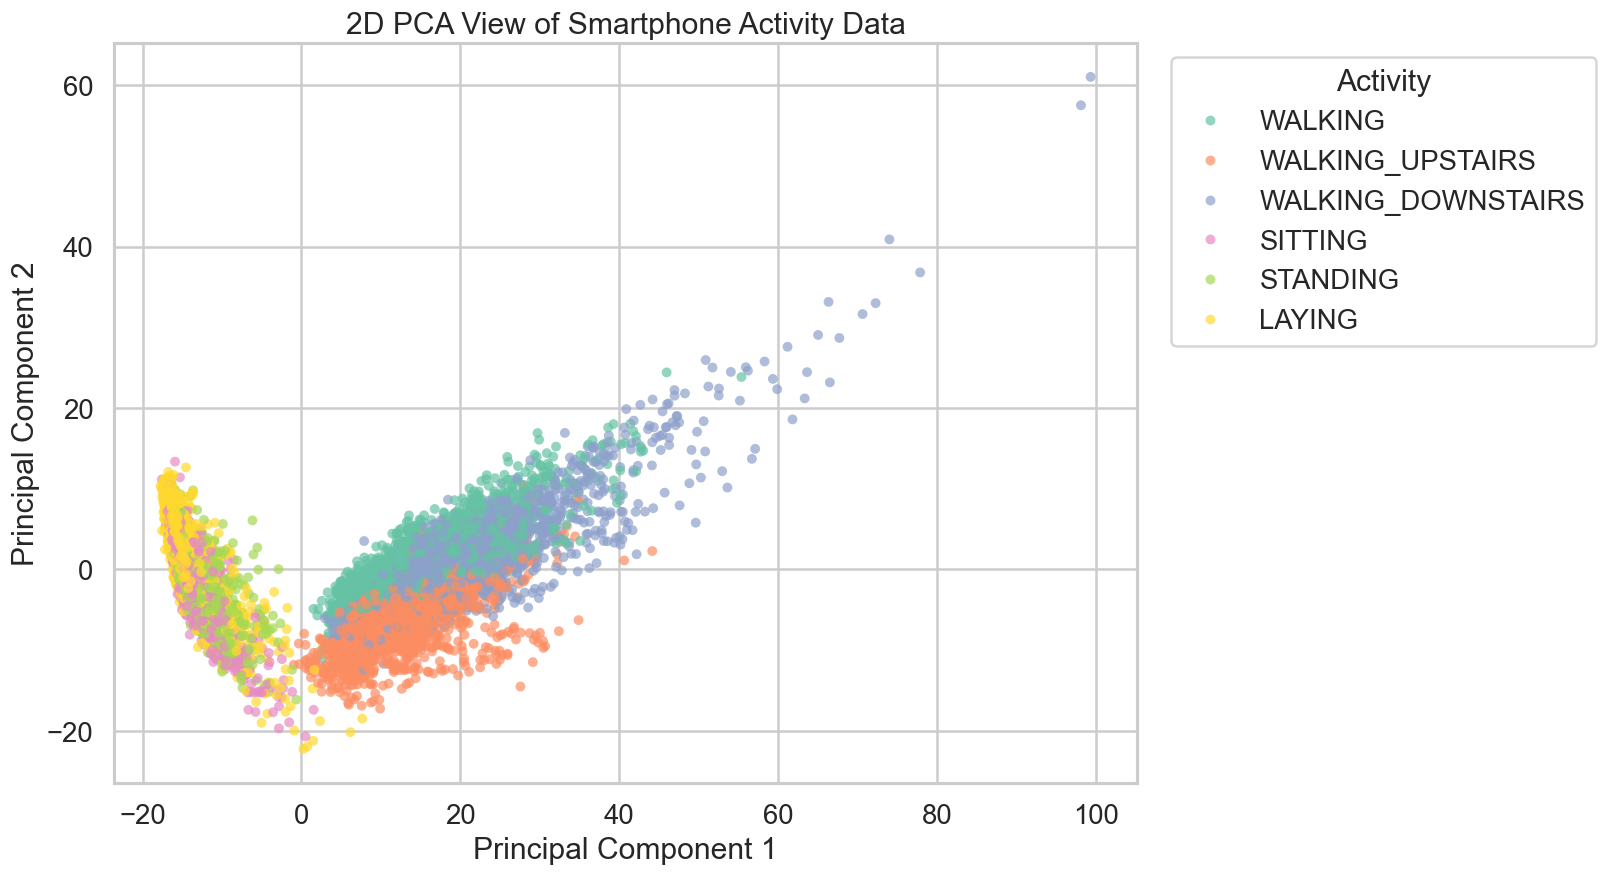

In [10]:
fig, ax = plot_pca_scatter(
    pca_scores_with_labels,
    save_path=paths["figures"] / "pca_2d_scatter.png",
)
plt.show()
plt.close(fig)

### Interpreting PC1 and PC2 in Plain English

The scatter plot is useful, but a presentation also needs a verbal reading of the axes.

The summaries below use:

- average activity centroids in the 2D PCA space,
- grouped loading summaries for the strongest features in each component.

These are not perfect labels for PC1 and PC2, but they give a defensible and audience-friendly interpretation of what the axes seem to capture.

In [11]:
component_profile_display = component_profile.rename(
    columns={
        "component": "Component",
        "top_domain": "Dominant domain",
        "domain_share": "Domain share",
        "top_sensor_family": "Dominant sensor family",
        "sensor_family_share": "Sensor family share",
        "top_feature_style": "Dominant feature style",
        "feature_style_share": "Feature style share",
    }
).copy()
for column in ["Domain share", "Sensor family share", "Feature style share"]:
    component_profile_display[column] = (
        component_profile_display[column] * 100
    ).round(1).astype(str) + "%"

activity_centroids_display = activity_centroids.rename(
    columns={
        "activity_label": "Activity",
        "sample_count": "Rows",
        "mean_pc1": "Mean PC1",
        "mean_pc2": "Mean PC2",
    }
).copy()
activity_centroids_display[["Mean PC1", "Mean PC2"]] = activity_centroids_display[["Mean PC1", "Mean PC2"]].round(2)

display(Markdown(f"### Simplified feature summary (based on the top {top_loading_window} absolute loadings per component)"))
display(component_profile_display)

display(Markdown("### Average 2D PCA position for each activity"))
display(activity_centroids_display)

dynamic_labels = {"WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"}
stationary_labels = {"SITTING", "STANDING", "LAYING"}

dynamic_pc1_mean = activity_centroids.loc[
    activity_centroids["activity_label"].isin(dynamic_labels), "mean_pc1"
].mean()
stationary_pc1_mean = activity_centroids.loc[
    activity_centroids["activity_label"].isin(stationary_labels), "mean_pc1"
].mean()

upstairs_pc2 = float(
    activity_centroids.loc[
        activity_centroids["activity_label"] == "WALKING_UPSTAIRS", "mean_pc2"
    ].iloc[0]
)
level_downstairs_pc2_mean = activity_centroids.loc[
    activity_centroids["activity_label"].isin(["WALKING", "WALKING_DOWNSTAIRS"]), "mean_pc2"
].mean()
laying_pc2 = float(
    activity_centroids.loc[
        activity_centroids["activity_label"] == "LAYING", "mean_pc2"
    ].iloc[0]
)
standing_pc2 = float(
    activity_centroids.loc[
        activity_centroids["activity_label"] == "STANDING", "mean_pc2"
    ].iloc[0]
)

pc1_domain_split = (
    loading_group_summary[
        (loading_group_summary["component"] == "PC1")
        & (loading_group_summary["grouping"] == "domain")
    ]
    .set_index("group_name")["share_of_top_loading_mass"]
)
pc1_profile = component_profile.loc[component_profile["component"] == "PC1"].iloc[0]
pc2_profile = component_profile.loc[component_profile["component"] == "PC2"].iloc[0]

interpretation_text = f"""
- **PC1** appears to act like a broad **movement-intensity axis**. The average PC1 score for the three walking activities is **{dynamic_pc1_mean:.1f}**, compared with **{stationary_pc1_mean:.1f}** for the three mostly stationary activities. The grouped loadings show that PC1 is driven mainly by **{str(pc1_profile['top_sensor_family']).lower()}** and **{str(pc1_profile['top_feature_style']).lower()}** features, with time-domain and frequency-domain contributions split almost evenly (**{pc1_domain_split.get('Time domain', 0):.0%}** vs **{pc1_domain_split.get('Frequency domain', 0):.0%}**). In plain English: higher PC1 scores mostly mean **more overall movement**.

- **PC2** appears to act more like a **finer movement-style axis**. `WALKING_UPSTAIRS` has a much lower average PC2 score (**{upstairs_pc2:.1f}**) than `WALKING` and `WALKING_DOWNSTAIRS` together (**{level_downstairs_pc2_mean:.1f}**), and `LAYING` sits above `STANDING` among the posture-based classes (**{laying_pc2:.1f}** vs **{standing_pc2:.1f}**). The grouped loadings suggest that PC2 leans most on **{str(pc2_profile['top_domain']).lower()}**, **{str(pc2_profile['top_sensor_family']).lower()}**, and **{str(pc2_profile['top_feature_style']).lower()}** features, so it seems to help distinguish **how the motion is happening**, not just whether the person is moving.
"""

display(Markdown(interpretation_text))

display(Markdown("### Optional appendix: raw top-loading features"))
display(top_loadings)

### Simplified feature summary (based on the top 40 absolute loadings per component)

,Component,Dominant domain,Domain share,Dominant sensor family,Sensor family share,Dominant feature style,Feature style share
0,PC1,Time domain,50.0%,Body acceleration,75.0%,Magnitude / overall intensity,75.1%
1,PC2,Time domain,72.8%,Gyroscope,35.6%,Frequency / coefficient pattern,93.5%


### Average 2D PCA position for each activity

,Activity,Rows,Mean PC1,Mean PC2
0,LAYING,1944,-14.56,2.13
1,SITTING,1777,-14.23,0.83
2,STANDING,1906,-13.63,-0.19
3,WALKING,1722,15.82,1.24
4,WALKING_DOWNSTAIRS,1406,23.32,2.13
5,WALKING_UPSTAIRS,1544,12.65,-6.72



- **PC1** appears to act like a broad **movement-intensity axis**. The average PC1 score for the three walking activities is **17.3**, compared with **-14.1** for the three mostly stationary activities. The grouped loadings show that PC1 is driven mainly by **body acceleration** and **magnitude / overall intensity** features, with time-domain and frequency-domain contributions split almost evenly (**50%** vs **50%**). In plain English: higher PC1 scores mostly mean **more overall movement**.

- **PC2** appears to act more like a **finer movement-style axis**. `WALKING_UPSTAIRS` has a much lower average PC2 score (**-6.7**) than `WALKING` and `WALKING_DOWNSTAIRS` together (**1.7**), and `LAYING` sits above `STANDING` among the posture-based classes (**2.1** vs **-0.2**). The grouped loadings suggest that PC2 leans most on **time domain**, **gyroscope**, and **frequency / coefficient pattern** features, so it seems to help distinguish **how the motion is happening**, not just whether the person is moving.


### Optional appendix: raw top-loading features

,component,feature_name,loading,absolute_loading
0,PC1,fBodyAcc-sma(),0.058616,0.058616
1,PC1,fBodyAccJerk-sma(),0.058578,0.058578
2,PC1,fBodyGyro-sma(),0.058553,0.058553
3,PC1,tBodyAccJerk-sma(),0.058549,0.058549
4,PC1,tBodyAccJerkMag-mean(),0.058495,0.058495
5,PC1,tBodyAccJerkMag-sma(),0.058495,0.058495
6,PC1,fBodyBodyAccJerkMag-mean(),0.058108,0.058108
7,PC1,fBodyBodyAccJerkMag-sma(),0.058108,0.058108
8,PC1,tBodyAccJerkMag-mad(),0.058003,0.058003
9,PC1,tBodyAccJerkMag-std(),0.057973,0.057973


## 7. Tie the Results Back to the Analytical Question

The answer is **yes, with clear limits**.

- PCA compresses the dataset from **561 features** to a simple **2D view** while keeping enough structure to separate the big activity families.
- **PC1** gives a strong broad split between dynamic movement and mostly stationary posture.
- **PC2** adds useful refinement, especially for activities that are related but not identical, such as different walking styles.
- The overlap between `SITTING` and `STANDING` shows the limit of a 2D linear summary: similar activities can still remain close together.
- The variance-threshold table reinforces the tradeoff: **2 PCs** are good for visualization, but **many more PCs** are needed if the goal is to retain most of the original information.

So PCA is clearly useful here as a structure-discovery tool, even though two components do not fully represent the full 561-feature dataset.

## 8. Takeaway and Limitations

PCA works well here for **broad separation and visualization**. In only two components, it gives a readable map of the dataset and makes the biggest split, moving activities versus mostly stationary activities, easy to explain.

At the same time, PCA is **not a perfect classifier**. Similar activities such as `SITTING` and `STANDING` still overlap, PCA is a **linear** method, and using only **2 PCs** is a deliberate simplification of a much richer 561-feature space.

That is the core takeaway: PCA is a strong **exploratory tool**, especially for communication and structure discovery, but it is weaker for fine-grained separation on its own.

## Saved Outputs

This notebook saves figures to `outputs/figures/` and summary tables to `outputs/tables/`, including the dimension-comparison table, the variance-threshold summary, grouped loading profiles, and the activity-centroid summaries.